In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# GPU 설정 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Enabled")
    except RuntimeError as e:
        print(e)

# Import or install Sionna
try:

    import sionna.rt
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Sionna RT의 주요 모듈 임포트
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, RadioMapSolver, PathSolver
from sionna.rt.utils import r_hat, subcarrier_frequencies
from sionna.rt import scene as share_scene

2025-12-06 18:55:08.612127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765043708.620532 3690243 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765043708.623190 3690243 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-06 18:55:08.632764: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU Enabled


In [2]:
# IEEE 802.11 OFDM 파라미터
carrier_frequency = 5e9  
ch_bandwidth = 20e6        # 20 MHz (Hz 단위)
v = 2                        # 2m/s
n_fft = 64                 # FFT 크기
cp_length = 16             # CP 길이 (샘플 수, 0.8us at 20MHz)
symbol_duration = 4e-6     # OFDM 심볼 길이 (초)
n_data = 48                # 데이터 서브캐리어 개수
n_pilot = 4                # 파일럿 서브캐리어 개수

In [3]:
# Sionna RT 내장 샘플 환경 사용
from sionna.rt import scene as sample_scene

# 예시 1: 작은 사무실 환경
scene = load_scene("/home/ccs-lab/yura.min/apartment/apartment.xml")

# 송신기(기지국) 안테나 배열 (1x1, 무지향성)
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="cross")

# 수신기(단말) 안테나 배열 (1x1, 무지향성)
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="cross")

# 송신기 생성 및 추가
tx = Transmitter(name="tx",
                 position=[-1.7, 1.7, 2.0],
                 look_at=[0, 0, 0],
                 display_radius=0.1)
scene.add(tx)
tx.array = scene.tx_array  # ← 이거 추가!
# 수신기 생성 및 추가 (시작 위치, Random Waypoint Model로 이후 이동)
rx = Receiver(name="rx",
              position=[-2.1, 5.8, 1.0],
              display_radius=0.1)
scene.add(rx)

tx.look_at(rx)  # 송신기가 수신기를 바라봄

# 3D 시각화용 카메라 설정

bird_cam = Camera(position=[0, 3, 15], look_at=[-3, 3, 0]) # 위에서 본 것


# IEEE 802.11 파라미터를 3D scene에 적용
scene.frequency = carrier_frequency
scene.bandwidth = ch_bandwidth



2025-12-06 18:55:13 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


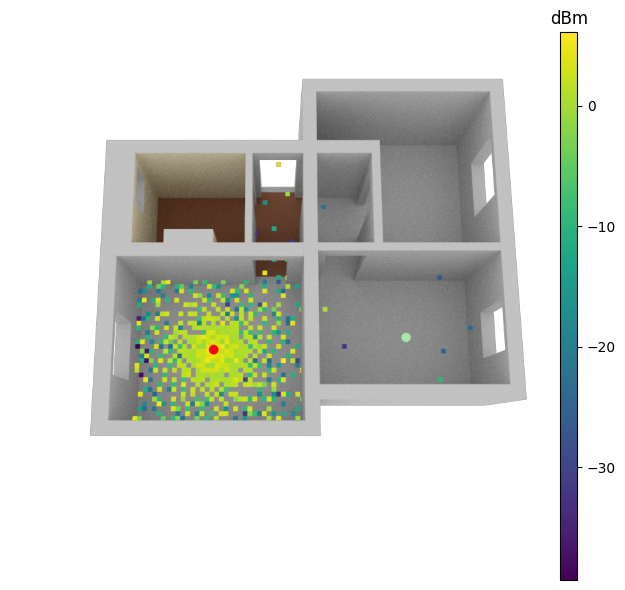

In [4]:
from sionna.rt import RadioMapSolver   # 꼭 추가!



max_depth = 4
cell_size = (0.1, 0.1)
samples_per_tx = 1000
resolution = (400, 400)

rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               max_depth=max_depth,
               cell_size=cell_size,
               samples_per_tx=samples_per_tx)

output = scene.render(
    camera=bird_cam,
    radio_map=rm,
                  # radio_map과 경로를 동시에
    resolution=(800, 800),
    rm_metric="rss",
    rm_show_color_bar=True,

)

Rendering at step 411, Rx position: [-1.6879594  5.46737    1.       ]
Rendering at step 521, Rx position: [-1.8634626  5.60003    1.       ]
Rendering at step 660, Rx position: [-2.0408034  5.4961824  1.       ]
Rendering at step 737, Rx position: [-2.1276426  5.369002   1.       ]
Rendering at step 740, Rx position: [-2.131026   5.3640466  1.       ]


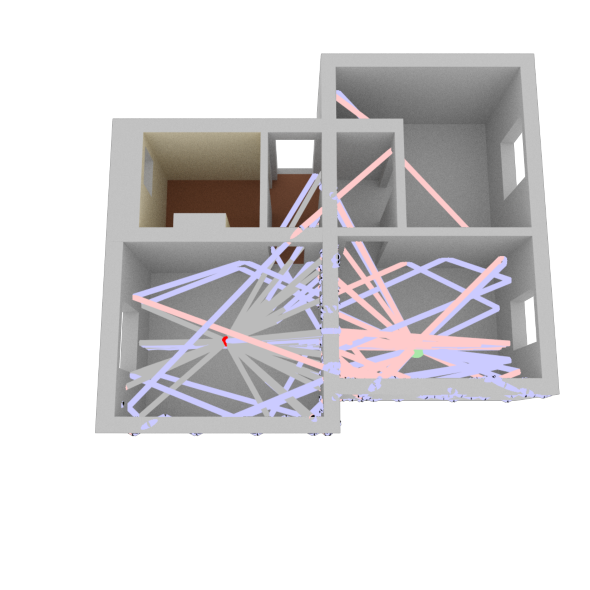

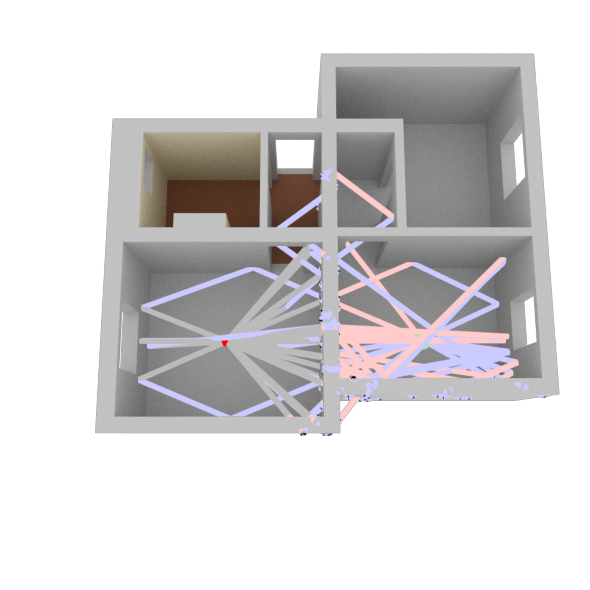

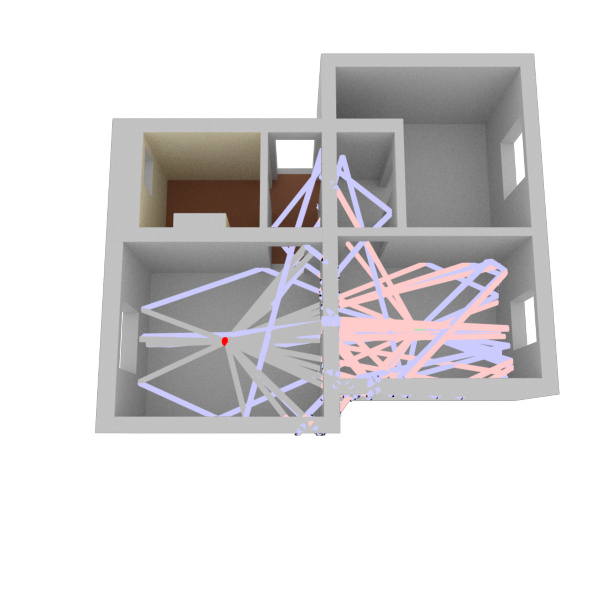

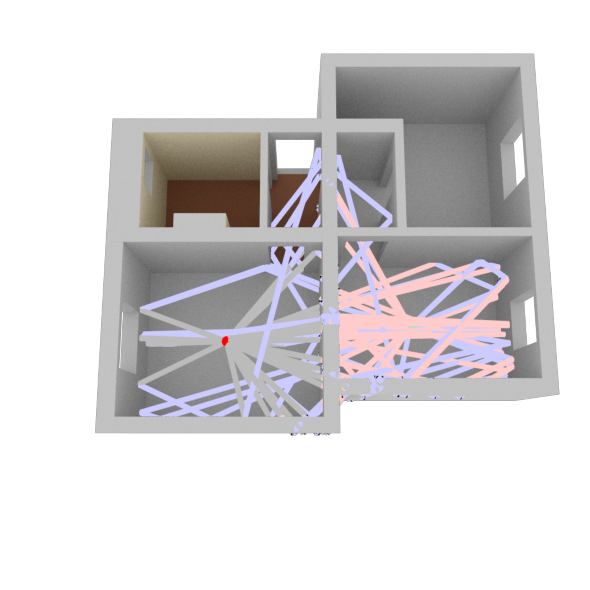

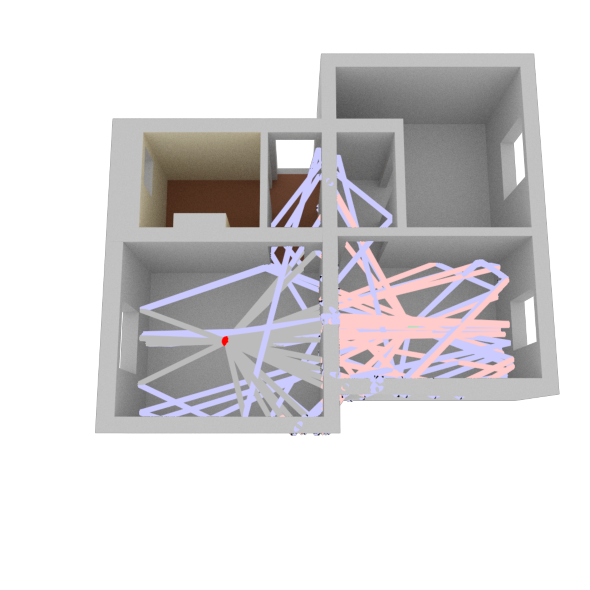

In [5]:
# Random Waypoint 생성 (방 내부로 제한)

def generate_random_waypoint_trajectory(
    area_bounds=[[-5, -0.5], [1, 7]],
    height=1.0,
    v=2.0,
    duration=1.0,
    dt=0.001,  # 시간 간격 살짝 여유
    threshold=1  # 목표 도달 판정 거리 크게
):
    num_steps = int(duration / dt)
    positions = []
    

# 초기 위치를 area_bounds 내에서 랜덤으로 설정
    x = np.random.uniform(area_bounds[0][0], area_bounds[0][1])
    y = np.random.uniform(area_bounds[1][0], area_bounds[1][1])
    pos = np.array([x, y])

    goal = None
    
    for _ in range(num_steps):
        if goal is None or np.linalg.norm(goal - pos) < threshold:
            # 새 목표 지점 샘플링 (이게 진짜 핵심!)
            x = np.random.uniform(area_bounds[0][0], area_bounds[0][1])
            y = np.random.uniform(area_bounds[1][0], area_bounds[1][1])
            goal = np.array([x, y])
            direction = goal - pos
            direction /= np.linalg.norm(direction)

        pos = pos + v * dt * direction
        positions.append([pos[0], pos[1], height])

    return np.array(positions, dtype=np.float32)

channel_taps_history = []
positions = generate_random_waypoint_trajectory()


# Velocity 추출 (finite difference)
dt=0.001
velocities = (positions[1:] - positions[:-1]) / dt
velocities = np.vstack([velocities, velocities[-1]])  # 마지막 스텝 보정

path_solver = PathSolver()

# 전체 time-evolution CIR 시퀀스 수집
time_cir_sequence = []
sampling_frequency = 1000  # 1kHz
num_time_steps = 1000  # time-evolution 길이

# 시각화 샘플링: 1000개 중 10개만 렌더링
np.random.seed(42)
render_indices = np.random.choice(len(positions), size=5, replace=False)


channels = []

for i, pos in enumerate(positions):
    try:
        scene.remove("rx")
    except KeyError:
        pass

    rx = Receiver(name="rx", 
                  position=pos.tolist(), 
                  display_radius=0.2,
                  velocity=velocities[i].tolist())
    scene.add(rx)
    tx.look_at(rx)

    paths = path_solver(scene=scene,
                        max_depth=20,  # 속도 최적화
                        max_num_paths_per_src=1000000,
                        los=True,
                        specular_reflection=True,
                        diffuse_reflection=True,
                        refraction=True,
                        synthetic_array=False,
                        seed=42)

    if i in render_indices:
        print(f"Rendering at step {i}, Rx position: {pos}")
        scene.render(camera=bird_cam, paths=paths, clip_at=20, resolution=(1024, 1024))


    cir_list = paths.cir()
    if len(cir_list[0]) == 0:
        ch = tf.zeros([1, 1, 1], dtype=tf.complex64)
    else:
        cir = cir_list[0][0]
        ch = cir

    channels.append(ch)

    # 3. CIR을 Taps로 변환 (스냅샷 저장)
    taps = paths.taps(bandwidth=ch_bandwidth, 
                      l_min=0, l_max=64,      # 0번부터 64번 탭까지만 저장
                      normalize=True, 
                      out_type="numpy")
    # 데이터 저장 (가장 강한 안테나 링크 하나만: index [0,0,0,0,0,:])
    channel_taps_history.append(taps[0,0,0,0,0,:]) # index [0,0,0,0,0,:]는 (Batch, Rx, RxAnt, Tx, TxAnt) 차원을 제거하고
    # 순수한 '탭(Delay Tap)' 데이터만 남기는 것입니다.

    # time-evolution CIR 수집
    a_mob, _ = paths.cir(sampling_frequency=1000, num_time_steps=1000, out_type="numpy")
    time_cir_sequence.append(a_mob[0,0,0,0,0,:])


channel_matrix = np.array(channel_taps_history)    
time_cir_sequence = np.stack(time_cir_sequence, axis=0)  # shape: [trajectory_steps, num_time_steps]

In [6]:
# positions: [ [x1,y1,z1], [x2,y2,z2], [x3,y3,z3] ... ]

# 1. (다음 위치) - (현재 위치) = 이동 거리 벡터
delta_pos = positions[1:] - positions[:-1] 

# 2. 이동 거리 / 시간 간격 = 속도 벡터
velocities = delta_pos / dt

print(velocities)

[[-1.595497   1.206398   0.       ]
 [-1.595497   1.2059212  0.       ]
 [-1.595497   1.2059212  0.       ]
 ...
 [-1.1277199 -1.6517638  0.       ]
 [-1.1279583 -1.6517638  0.       ]
 [-1.1277199 -1.6517638  0.       ]]


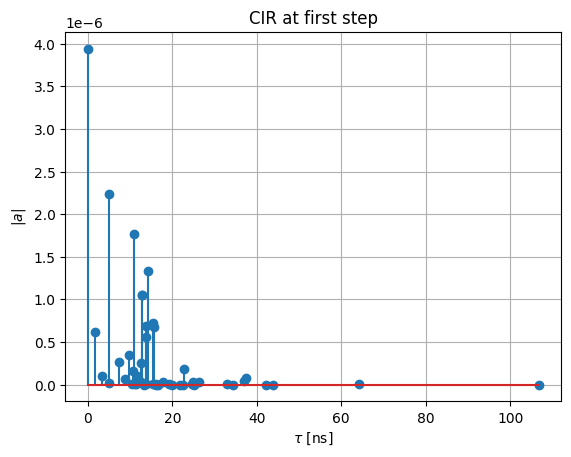

In [7]:
# CIR 시퀀스 수집 전용 "무선 채널의 충격 응답(CIR, Channel Impulse Response)을 계산하고, 그중 첫 번째 순간의 '메아리(Multipath)'들을 시각화하는 코드입니다. 
# 쉽게 비유하자면, **"방 안에서 손뼉을 딱! 쳤을 때, 소리가 직접 들리는 것과 벽에 튕겨서 늦게 들리는 메아리들이 각각 언제, 얼마나 크게 들리는지 그래프로 그리는 것입니다.

a_np_list = []
tau_np_list = []
a_np, tau_np = paths.cir(normalize_delays=True, out_type="numpy")
a_np_list.append(a_np)
tau_np_list.append(tau_np)

# 예: 첫번째 스텝의 CIR 시각화
t = tau_np_list[0][0,0,0,0,:]/1e-9
a_abs = np.abs(a_np_list[0])[0,0,0,0,:,0]

plt.figure()
plt.title("CIR at first step")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$")
plt.grid(True)
plt.show()

#이 코드를 돌려서 알 수 있는 것:
#전파 환경이 얼마나 복잡한가? (막대가 1개면 깔끔한 환경, 막대가 수십 개면 반사가 심한 복잡한 방)

#지연 확산(Delay Spread): 마지막 메아리가 얼마나 늦게 도착하는가? (이게 길어지면 통신 속도를 높이기 어렵습니다.)

##신호 세기: 수신기가 현재 위치에서 신호를 얼마나 강하게 받고 있는가?

Shape of h_freq:  (1, 2, 1, 2, 1, 64)


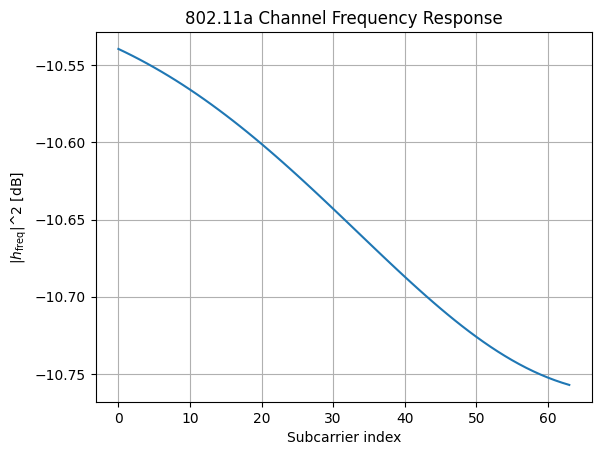

In [8]:
#CIR을 푸리에 변환, 각 주파수 별로 신호가 얼마나 세게, 혹은 약하게 도달하는지

# OFDM system parameters for 802.11a
num_subcarriers = 64
subcarrier_spacing = 312.5e3  # 312.5 kHz

# Compute frequencies of subcarriers relative to carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response from paths
h_freq = paths.cfr(frequencies=frequencies,
                   normalize=False,
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot CFR
plt.figure()
plt.plot(np.log10(np.abs(h_freq)[0,0,0,0,0,:] ** 2));
plt.xlabel("Subcarrier index")
plt.ylabel(r"|$h_\text{freq}$|^2 [dB]")
plt.title("802.11a Channel Frequency Response")
plt.grid(True)
plt.show()


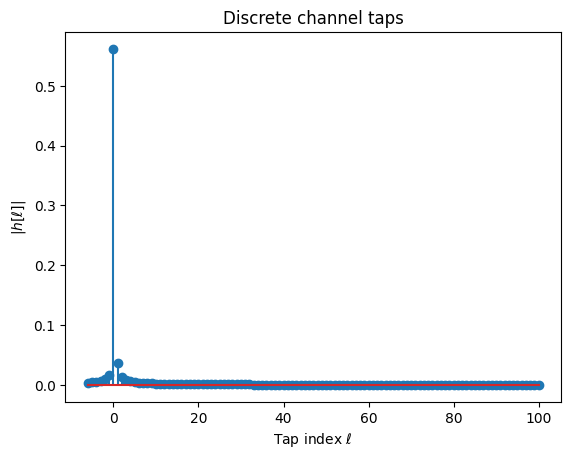

In [9]:
#이 코드는 앞서 구했던 **물리적인 전파 경로(Analog/Continuous)**를 디지털 통신 시스템이 처리할 수 있는 이산적인 디지털 필터(Digital/Discrete Taps) 형태로 변환하는 과정입니다.
#쉽게 말해, "현실 세계의 메아리(CIR)를 컴퓨터(DSP)가 이해할 수 있는 숫자의 배열로 '샘플링'해서 옮겨 담는 작업"입니다.

(frequencies[-1] - frequencies[0]) / 1e6 #대역폭 계산. 대역폭이 넓을수록 시간 축에서 더 촘촘하게(미세하게) 채널을 쪼개서 볼 수 있습니다.

taps = paths.taps(bandwidth=ch_bandwidth,
                      l_min=-6, l_max=100, #채널을 최대 100샘플 길이까지 보겠다
                      normalize=True,
                      normalize_delays=True,
                      out_type="numpy")

# 시퀀스 시각화 (PDP heatmap)
plt.figure()
plt.stem(np.arange(-6, 101), np.abs(taps)[0,0,0,0,0]);
plt.xlabel(r"Tap index $\ell$");
plt.ylabel(r"|$h[\ell]|$");
plt.title("Discrete channel taps");
plt.show()

#관찰: **0번 인덱스(Tap 0)**의 값이 약 0.65로 가장 크고, 나머지 탭들은 상대적으로 매우 작습니다.

#분석:이는 전파 에너지의 90% 이상이 **가장 먼저 도착하는 샘플(LoS 경로)**에 집중되어 있다는 뜻입니다.
#통신 이론에서는 이를 "Frequency Flat Fading(주파수 비선택적 페이딩)" 환경이라고 부릅니다.
#의미: 수신기는 복잡한 신호 처리를 할 필요 없이, 0번 탭의 신호만 잘 잡아내면 원본 데이터를 거의 완벽하게 복구할 수 있습니다.


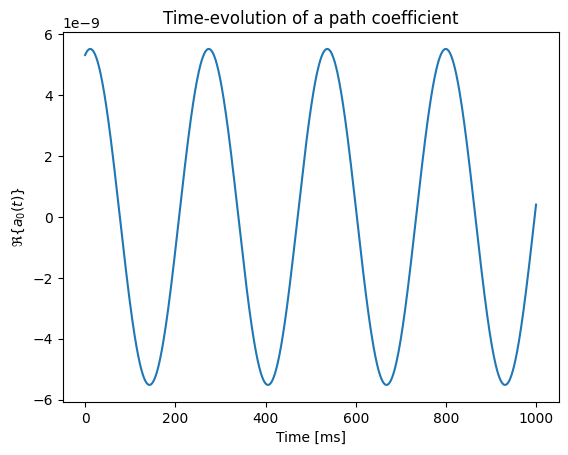

In [10]:
#로봇이 움직임에 따라 발생하는 도플러 효과로 인해 신호가 시간 흐름에 따라 어떻게 출렁이는지(Fading)

sampling_frequency = 1000  # 1kHz

# 시각화
plt.figure()
plt.plot(np.arange(num_time_steps)/sampling_frequency*1000,
         a_mob[0,0,0,0,0].real);
plt.xlabel("Time [ms]");
plt.ylabel(r"$\Re\{a_0(t) \}$");
plt.title("Time-evolution of a path coefficient");

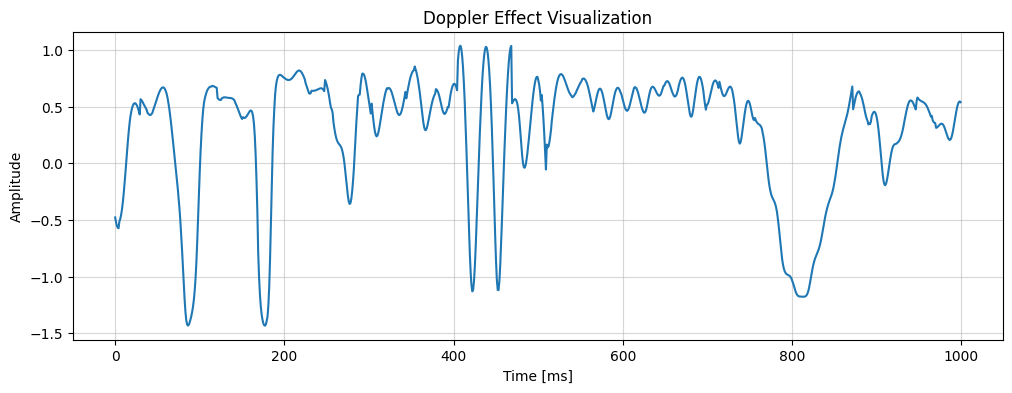

In [11]:
# [Cell 3] 도플러 및 채널 히트맵 시각화

# 2. 도플러 진동 확인 (LoS Path 위상 변화)
# 0번 탭(주로 LoS)의 실수부(Real part)를 그려서 진동 확인
los_signal = channel_matrix[:, 0] 

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(positions))*dt*1000, np.real(los_signal))
plt.title("Doppler Effect Visualization")
plt.xlabel("Time [ms]")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.5)
#plt.xlim(0, 200) # 앞부분 200ms만 확대해서 파형 자세히 보기 (필요시 제거)
plt.show()

Shape of b_mob:  (1, 2, 1, 2, 1000, 64)


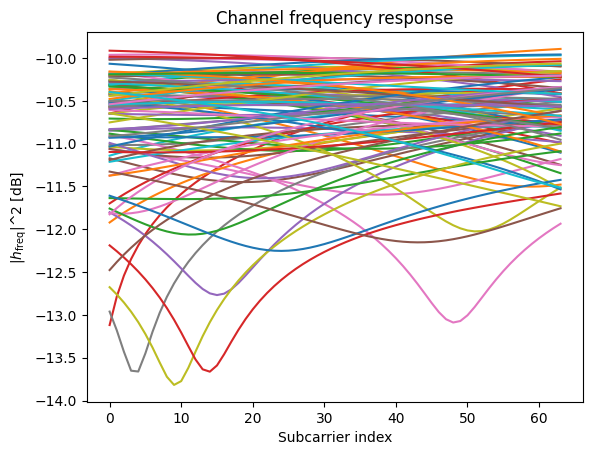

In [12]:
b_mob = paths.cfr(sampling_frequency=sampling_frequency,
                         num_time_steps=num_time_steps,
                         frequencies=frequencies,
                         out_type="numpy")
print("Shape of b_mob: ", b_mob.shape)

# Plot absolute value
plt.figure()
for idx in range(0, num_time_steps, 10):
    plt.plot(np.log10(np.abs(b_mob)[0,0,0,0,idx,:] ** 2));
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|^2 [dB]");
plt.title("Channel frequency response");

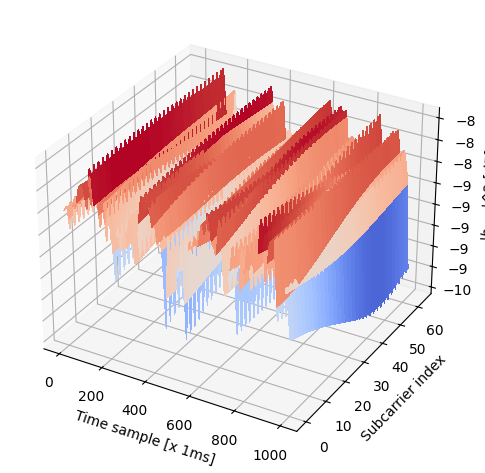

In [13]:
X = np.arange(0, b_mob.shape[4])
Y = np.arange(0, b_mob.shape[5])
X, Y = np.meshgrid(X, Y)
X.shape

Z = np.zeros((b_mob.shape[5], b_mob.shape[4]))
Z.shape

for idx in range(0, num_time_steps):
    Z[:,idx] = np.log10(np.abs(b_mob)[0,0,0,0,idx,:] ** 2)
    #Z[:,idx] = np.angle(b_mob)[0,0,0,0,idx,:]
    
    # Plot the surface.
from matplotlib import cm
from matplotlib.ticker import LinearLocator


fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
#ax.set_zlim(-1.01, 1.01)
#ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.0f}')

# Add a color bar which maps values to colors.
#fig.colorbar(surf, shrink=0.2, aspect=5)
ax.set_xlabel("Time sample [x 1ms]");
ax.set_ylabel("Subcarrier index");
ax.set_zlabel(r"|$h_\text{freq}$|^2 [dB]");
plt.tight_layout()
plt.show()

In [13]:
import scipy.io
import numpy as np

# ---------------------------------------------------------
# 1. CFR 정리: b_mob -> CFR (Time, Subcarrier)
# ---------------------------------------------------------
# b_mob: [B, R, TB, Tx, T, K]
B, R, TB, Tx, T, K = b_mob.shape
print("b_mob shape:", b_mob.shape)

# 한 링크(예: B=0, R=0, TB=0, Tx=0)만 선택해서 [T, K]로 사용
# 필요하면 R, Tx 인덱스를 바꿔서 다른 안테나 조합을 고를 수 있음
h_cfr_clean = b_mob[0, 0, 0, 0, :, :]   # (T, K)

CFR = h_cfr_clean.astype(np.complex64, copy=False)
print("CFR shape:", CFR.shape, "(Time x Subcarriers)")


# ---------------------------------------------------------
# 2. CIR 정리: paths.cir() -> CIR_amp, CIR_delay
# ---------------------------------------------------------
# sampling_frequency, num_time_steps 는 앞 셀에서 이미 정의됨
a_cir, tau_cir = paths.cir(
    sampling_frequency=sampling_frequency,
    num_time_steps=num_time_steps,
    normalize_delays=True
)

# TensorFlow 텐서일 수도 있으니 numpy로 변환
if hasattr(a_cir, "numpy"):
    a_cir = a_cir.numpy()
if hasattr(tau_cir, "numpy"):
    tau_cir = tau_cir.numpy()

# 불필요한 차원 제거
a_cir_clean = np.squeeze(a_cir)      # 보통 [Paths, Time] 또는 [Time, Paths] 중 하나
tau_cir_clean = np.squeeze(tau_cir)  # [Paths]

# 형태를 (Time, Paths)로 맞추기
if a_cir_clean.shape[0] != num_time_steps and a_cir_clean.shape[-1] == num_time_steps:
    a_cir_clean = a_cir_clean.T

CIR_amp = a_cir_clean
CIR_delay = tau_cir_clean

print("CIR_amp shape:", CIR_amp.shape, "(Time x Paths)")
print("CIR_delay shape:", CIR_delay.shape, "(Paths)")

# ---------------------------------------------------------
# 3. 축 정보 & 메타데이터
# ---------------------------------------------------------
# 시간 축: 초 단위
time_axis = np.arange(num_time_steps) / float(sampling_frequency)

# 주파수 축: subcarrier_frequencies()로 만든 frequencies 변수 재사용
# (Sionna 텐서일 수 있으니 numpy로 변환)
freq_axis = frequencies.numpy() if hasattr(frequencies, "numpy") else frequencies

num_subcarriers = K
subcarrier_spacing = ch_bandwidth / num_subcarriers  # 20MHz / 64 = 312.5kHz (이론상)

# ---------------------------------------------------------
# 4. .mat로 저장할 딕셔너리 구성
# ---------------------------------------------------------
mat_data = {
    # --- 핵심 데이터 ---
    "CFR": CFR,                # (Time, Subcarrier) 복소수 주파수 도메인 CSI
    "CIR_amp": CIR_amp,        # (Time, Paths) 복소수 임펄스 응답 계수
    "CIR_delay": CIR_delay,    # (Paths,) 지연 (초 또는 내부 단위)

    # --- 축 정보 ---
    "time_axis": time_axis,    # (Time,) 시간축 [s]
    "freq_axis": freq_axis,    # (Subcarrier,) 주파수축 [Hz]

    # --- 설정 값 ---
    "num_subcarriers": num_subcarriers,
    "subcarrier_spacing": subcarrier_spacing,
    "sampling_frequency": float(sampling_frequency),  # [Hz]

    # --- 이동 정보 (옵션) ---
    "positions": positions,    # (N, 3) Rx 궤적
    "velocities": velocities,  # (N, 3) Rx 속도
    "param_dt": dt,            # 시뮬레이션 시간 간격 [s]
    "param_fc": carrier_frequency,  # 중심 주파수 [Hz]
}

# ---------------------------------------------------------
# 5. 파일명 자동 생성 (기존 포맷 유지)
# ---------------------------------------------------------
freq_str = f"{carrier_frequency/1e9:.1f}GHz"   # 예: 5.0GHz
vel_str  = f"{v:.1f}m_s"                       # 예: 2.0m_s
bw_str   = f"{ch_bandwidth/1e6:.0f}MHz"        # 예: 20MHz
dt_str   = f"{dt*1000:.1f}ms"                  # 예: 1.0ms

filename = f"cfr_Fc={freq_str}_v={vel_str}_BW={bw_str}_dt={dt_str}_csi_dataset.mat"
print(f"📂 저장될 파일명: {filename}")

# ---------------------------------------------------------
# 6. .mat 파일 저장
# ---------------------------------------------------------
scipy.io.savemat(filename, mat_data, do_compression=True)
print("✅ 저장 완료!")


b_mob shape: (1, 2, 1, 2, 1000, 64)
CFR shape: (1000, 64) (Time x Subcarriers)
CIR_amp shape: (1000, 47, 2, 2, 2) (Time x Paths)
CIR_delay shape: (2, 2, 47) (Paths)
📂 저장될 파일명: cfr_Fc=5.0GHz_v=2.0m_s_BW=20MHz_dt=1.0ms_csi_dataset.mat
✅ 저장 완료!


In [19]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. 파일 로드
data = scipy.io.loadmat(f"cfr_Fc={freq_str}_v={vel_str}_BW={bw_str}_dt={dt_str}_csi_dataset.mat")
csi = data['CFR']   # Shape 예상: (1000, 64, 1, 1)
t_ms = data['time_axis'][0]
f_hz = data['freq_axis'][0]

print(f"📊 데이터 형태(Shape): {csi.shape}")
print(f"⏱️ 시간 길이: {t_ms[-1] - t_ms[0]:.1f} ms")
print(f"📡 주파수 대역: {len(f_hz)}개 부반송파")

# 복소수 데이터 분리
csi_mag = np.abs(csi[:, :, 0, 0])   # 크기 (Amplitude)
csi_pha = np.angle(csi[:, :, 0, 0]) # 위상 (Phase)

# 2. 시각화 (엑스레이 촬영)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# (왼쪽) 크기(Magnitude) - 전력이 얼마나 센가?
# 전치(.T)를 해서 시간(X축) vs 주파수(Y축)으로 봅니다.
im1 = ax[0].imshow(10*np.log10(csi_mag.T**2), aspect='auto', cmap='inferno', origin='lower')
ax[0].set_title("CSI Magnitude (Power) [dB]")
ax[0].set_xlabel("Time [ms]")
ax[0].set_ylabel("Subcarrier Index")
plt.colorbar(im1, ax=ax[0])

# (오른쪽) 위상(Phase) - 도플러가 보이는가? (가장 중요!)
im2 = ax[1].imshow(csi_pha.T, aspect='auto', cmap='twilight', origin='lower')
ax[1].set_title("CSI Phase (Doppler Pattern) [rad]")
ax[1].set_xlabel("Time [ms]")
ax[1].set_ylabel("Subcarrier Index")
plt.colorbar(im2, ax=ax[1])

plt.tight_layout()
plt.show()

📊 데이터 형태(Shape): (1000, 64)
⏱️ 시간 길이: 1.0 ms
📡 주파수 대역: 64개 부반송파


IndexError: too many indices for array: array is 2-dimensional, but 4 were indexed